# Part 1: Recurrent Neural Networks: Author Identification Bot

**Fullname:** Phalanndwa Munyai - ST10356476  
**Dataset:** Victorian Era Authorship Attribution (UCI Machine Learning Repository)  
**Link:** https://archive.ics.uci.edu/dataset/454/victorian+era+authorship+attribution

## Contents
Environment setup
1. Dataset evaluation and justification
2. Analysis plan
3. Exploratory Data Analysis (Spark)
4. Feature selection (Spark)
5. Data preparation for the LSTM
6. Model training
7. Model evaluation
8. Retraining with improved parameters
9. Author-guessing bot demo
10. References and code attribution

## Environment setup

In [5]:
# Start a local Spark session using Java 17
import os, sys, glob
from pyspark.sql import SparkSession

jdk = glob.glob(r"C:\Program Files\Eclipse Adoptium\jdk-17*")[0]
os.environ["JAVA_HOME"] = jdk
os.environ["PATH"] = os.path.join(jdk, "bin") + os.pathsep + os.environ["PATH"]

# Make Spark workers use the same Python as the notebook
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (SparkSession.builder
         .appName("VictorianAuthorLSTM")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
print("Java:", jdk)
print("Spark", spark.version)

Java: C:\Program Files\Eclipse Adoptium\jdk-17.0.20.101-hotspot
Spark 4.2.0


## 1. Dataset evaluation and justification
- **Source:** public UCI dataset (Gungor, 2018), built specifically to benchmark authorship attribution.
- **Size:** 53,678 labelled passages (well above the 10,000 minimum).
- **Structure:** each record is a 1,000-word text sequence plus an author ID, i.e. a sequence classification problem.
- **Why an LSTM fits:** writing style lives in word order, phrasing and sentence rhythm; LSTMs keep a memory of earlier words in a sequence.
- **Limitations:** text is lowercased with punctuation removed; only the 10,000 most frequent corpus words were kept; the official test file has no labels, so only the training file is used and split.

## 2. Analysis plan
| Stage | Action | Why |
|---|---|---|
| **EDA** | Check missing values, duplicates, class balance, passage length, lexical richness, function-word usage, top words | Confirm the data is clean and find patterns that matter for training |
| **Feature selection** | Keep top 10 authors; chi-square test (p-values) on word presence to find discriminative words and justify vocabulary size; choose sequence length | Balance accuracy against CPU training time; keep words that carry style signal |
| **Train model** | Embedding (10k vocab, 128 dims) → LSTM (64 units) → Dropout (0.3) → Dense softmax (10). Adam, lr 0.001, batch 64, up to 10 epochs, early stopping, class weights. 70/15/15 stratified split | Standard LSTM text classifier; class weights handle imbalance |
| **Evaluate** | Accuracy, macro F1, per-author precision/recall, confusion matrix, learning curves | Macro F1 treats small authors fairly; confusion matrix shows which authors are mixed up |
| **Retrain** | Address weaknesses found (e.g. overfitting, short context), for example by splitting passages into shorter chunks or tuning dropout/units | Show measured improvement over the baseline |
| **Report** | Data cleaning, EDA visuals, training setup, results, improvements, limitations | Required deliverable (PDF, succinct) |

## 3. Exploratory Data Analysis
### 3.1 Load the data


In [6]:
# Load the training CSV with Spark and cast author to integer
from pyspark.sql import functions as F

df = (spark.read
      .option("header", True)
      .option("encoding", "ISO-8859-1")   # file isn't UTF-8
      .option("multiLine", True)
      .option("escape", '"')
      .csv("data/Gungor_2018_VictorianAuthorAttribution_data-train.csv"))

df = df.withColumn("author", F.col("author").cast("int"))

df.printSchema()
print("Rows:", df.count())
df.show(3, truncate=100)

root
 |-- text: string (nullable = true)
 |-- author: integer (nullable = true)

Rows: 53678
+----------------------------------------------------------------------------------------------------+------+
|                                                                                                text|author|
+----------------------------------------------------------------------------------------------------+------+
|ou have time to listen i will give you the entire story he said it may form the basis of a future...|     1|
|wish for solitude he was twenty years of age and in the possession of perfect health most youths ...|     1|
|and the skirt blew in perfect freedom about the upper parts she wore no hat and her hair hung in ...|     1|
+----------------------------------------------------------------------------------------------------+------+
only showing top 3 rows


### 3.2 Data quality and class balance

In [7]:
# Data quality checks: nulls, duplicates, passages per author
# Missing values per column
df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

# Duplicate passages
print("Duplicates:", df.count() - df.dropDuplicates(["text"]).count())

# Passages per author (class balance)
df.groupBy("author").count().orderBy(F.desc("count")).show(50)

+----+------+
|text|author|
+----+------+
|   0|     0|
+----+------+

Duplicates: 0
+------+-----+
|author|count|
+------+-----+
|     8| 6914|
|    26| 4441|
|    14| 2696|
|    37| 2387|
|    45| 2312|
|    21| 2307|
|    39| 2266|
|    48| 1825|
|    33| 1742|
|    19| 1543|
|     4| 1483|
|    15| 1460|
|    43| 1266|
|    38| 1163|
|    25| 1159|
|     9| 1108|
|    18| 1078|
|    42| 1022|
|    30|  972|
|    50|  914|
|     1|  912|
|    41|  911|
|    28|  823|
|    10|  755|
|    32|  703|
|    36|  693|
|    17|  660|
|    35|  659|
|    29|  645|
|    12|  627|
|    46|  605|
|    20|  587|
|    22|  495|
|    13|  485|
|    44|  468|
|    23|  455|
|    34|  453|
|    40|  430|
|     6|  407|
|    11|  383|
|     2|  382|
|    24|  380|
|    27|  306|
|     3|  213|
|    16|  183|
+------+-----+



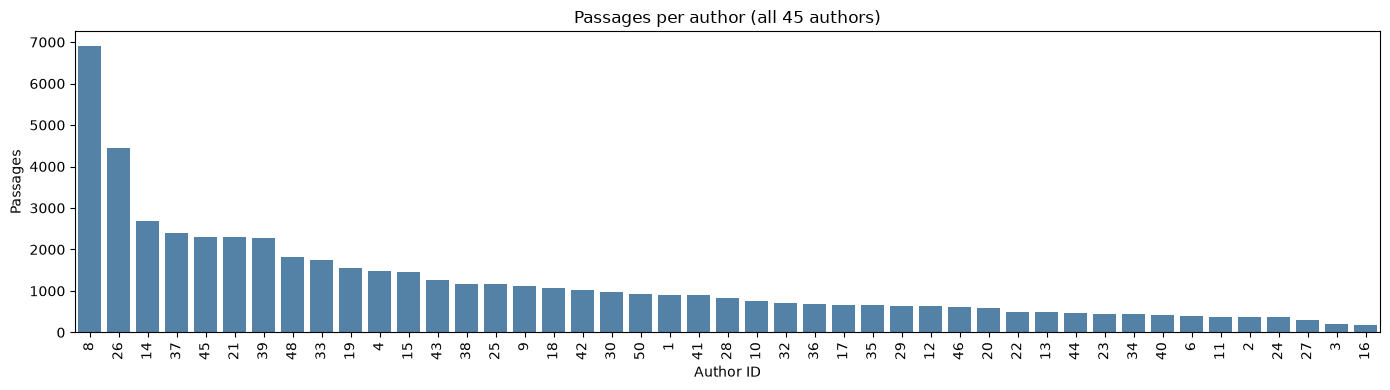

In [8]:
# Visualise class balance across all authors
import matplotlib.pyplot as plt
import seaborn as sns

counts_pd = df.groupBy("author").count().orderBy(F.desc("count")).toPandas()

plt.figure(figsize=(14, 4))
sns.barplot(data=counts_pd, x="author", y="count", order=counts_pd["author"], color="steelblue")
plt.title("Passages per author (all 45 authors)")
plt.xlabel("Author ID"); plt.ylabel("Passages")
plt.xticks(rotation=90)
plt.tight_layout(); plt.show()

### 3.3 Hidden padding check
The dataset description says short segments were padded to 1,000 words. This checks whether any passages contain padding tokens.

In [9]:
# Count '0' tokens (padding) per passage
padding = (df.withColumn("words", F.split(F.trim("text"), r"\s+"))
             .withColumn("pad_tokens", F.size(F.filter("words", lambda w: w == "0"))))

padding.select(
    F.sum((F.col("pad_tokens") > 0).cast("int")).alias("passages_with_padding"),
    F.max("pad_tokens").alias("max_padding_tokens")
).show()

+---------------------+------------------+
|passages_with_padding|max_padding_tokens|
+---------------------+------------------+
|                    0|                 0|
+---------------------+------------------+



### 3.4 Selecting the top 10 authors

The ten most represented authors were retained because they provide 28,433 passages, while the smallest retained class still contains 1,543 passages. This reduces the largest-to-smallest class imbalance from approximately 38:1 across all authors to about 4.5:1. Training ten classes is also substantially more practical on a CPU than training 45 classes, and the least represented authors would provide too few examples for reliable validation and testing.

In [10]:
# Keep only the 10 authors with the most passages
top10 = [r["author"] for r in df.groupBy("author").count()
         .orderBy(F.desc("count")).limit(10).collect()]
print("Top 10 author IDs:", top10)

df10 = df.filter(F.col("author").isin(top10)).cache()
print("Passages kept:", df10.count())

Top 10 author IDs: [8, 26, 14, 37, 45, 21, 39, 48, 33, 19]
Passages kept: 28433


### 3.5 Passage length

Every passage contains exactly 1,000 words. Therefore, passage length does not provide a useful signal for distinguishing authors. It does, however, determine how the text should be prepared: reading all 1,000 words would increase CPU cost and make optimisation harder, so the baseline reads a fixed 250-word sequence and the improved model uses shorter chunks.

In [11]:
# Words per passage (overall and per author)
df10 = df10.withColumn("word_count", F.size(F.split(F.trim(F.col("text")), r"\s+")))

df10.select("word_count").summary("count", "min", "25%", "50%", "75%", "max").show()
df10.groupBy("author").agg(F.round(F.avg("word_count"), 1).alias("avg_words")).orderBy("author").show()

+-------+----------+
|summary|word_count|
+-------+----------+
|  count|     28433|
|    min|      1000|
|    25%|      1000|
|    50%|      1000|
|    75%|      1000|
|    max|      1000|
+-------+----------+

+------+---------+
|author|avg_words|
+------+---------+
|     8|   1000.0|
|    14|   1000.0|
|    19|   1000.0|
|    21|   1000.0|
|    26|   1000.0|
|    33|   1000.0|
|    37|   1000.0|
|    39|   1000.0|
|    45|   1000.0|
|    48|   1000.0|
+------+---------+



### 3.6 Lexical richness per author
Vocabulary richness (unique words per 1,000) and average word length are classic stylometric features. Differences suggest authors are distinguishable by style.

+------+---------------------+---------------+
|author|unique_words_per_1000|avg_word_length|
+------+---------------------+---------------+
|     8|                397.3|            3.9|
|    14|                404.9|           3.88|
|    19|                388.3|           3.99|
|    21|                387.7|            3.9|
|    26|                397.8|           4.03|
|    33|                417.9|           3.93|
|    37|                407.4|           4.13|
|    39|                387.9|           3.73|
|    45|                417.7|           3.96|
|    48|                420.0|           3.99|
+------+---------------------+---------------+



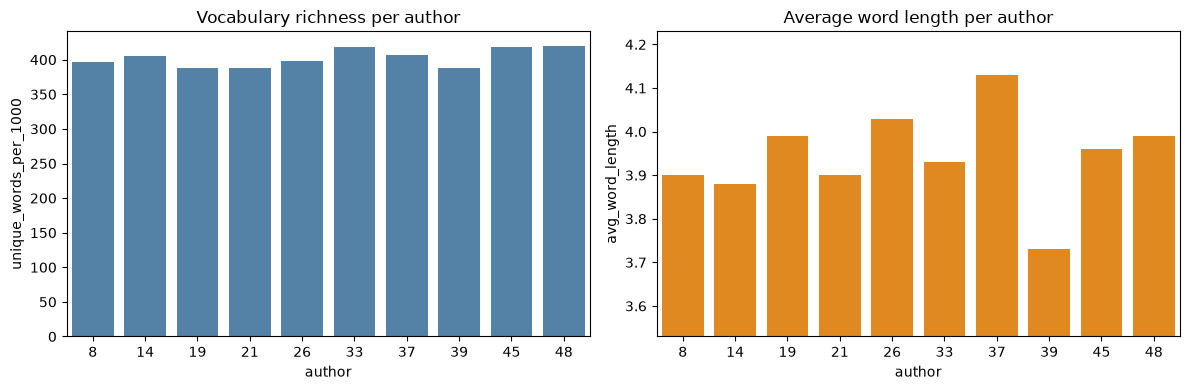

In [12]:
# Unique words and average word length per passage, averaged per author
lex = (df10.withColumn("words", F.split(F.trim("text"), r"\s+"))
           .withColumn("unique_words", F.size(F.array_distinct("words")))
           .withColumn("avg_word_len",
                       F.aggregate(F.transform("words", lambda w: F.length(w)), F.lit(0),
                                   lambda acc, x: acc + x) / F.size("words"))
           .groupBy("author")
           .agg(F.round(F.avg("unique_words"), 1).alias("unique_words_per_1000"),
                F.round(F.avg("avg_word_len"), 2).alias("avg_word_length"))
           .orderBy("author"))
lex.show()

lex_pd = lex.toPandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=lex_pd, x="author", y="unique_words_per_1000", ax=axes[0], color="steelblue")
axes[0].set_title("Vocabulary richness per author")
sns.barplot(data=lex_pd, x="author", y="avg_word_length", ax=axes[1], color="darkorange")
axes[1].set_title("Average word length per author")
axes[1].set_ylim(lex_pd["avg_word_length"].min() - 0.2, lex_pd["avg_word_length"].max() + 0.1)
plt.tight_layout(); plt.show()

### 3.7 Function-word usage (writing style fingerprint)
Common words like *the, and, of, but* are used unconsciously and at different rates by each author. This is why stopwords will **not** be removed before training the LSTM.

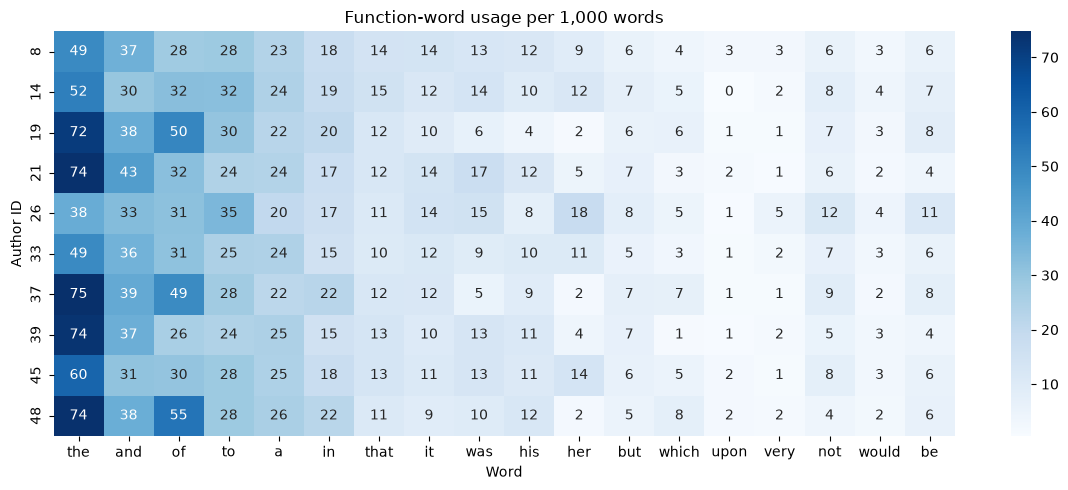

In [13]:
# Rate per 1,000 words of common function words, per author
function_words = ["the", "and", "of", "to", "a", "in", "that", "it", "was", "his",
                  "her", "but", "which", "upon", "very", "not", "would", "be"]

fw = (df10.select("author", F.explode(F.split(F.trim("text"), r"\s+")).alias("word"))
          .groupBy("author").agg(
              *[(F.sum((F.col("word") == w).cast("int")) / F.count("*") * 1000).alias(w)
                for w in function_words]))

fw_pd = fw.toPandas().set_index("author").sort_index()
plt.figure(figsize=(12, 5))
sns.heatmap(fw_pd, annot=True, fmt=".0f", cmap="Blues")
plt.title("Function-word usage per 1,000 words")
plt.xlabel("Word"); plt.ylabel("Author ID")
plt.tight_layout(); plt.show()

### 3.8 Most common content words per author

The most frequent content words indicate differences in subject matter and genre. For example, author 19 is associated with words such as *state*, *states* and *new*, while author 37 is associated with *nature* and *life*. Some authors use dialogue-related words such as *said*, *mrs* and *miss* more often. Few character names dominate the lists, which reduces the risk that the classifier relies only on easily memorised names instead of broader writing style.

In [14]:
# Top 8 non-stopword words per author
from pyspark.ml.feature import Tokenizer, StopWordsRemover
from pyspark.sql.window import Window

tokens = Tokenizer(inputCol="text", outputCol="words").transform(df10)
tokens = StopWordsRemover(inputCol="words", outputCol="filtered").transform(tokens)

word_counts = (tokens.select("author", F.explode("filtered").alias("word"))
               .filter(F.length("word") > 2)
               .groupBy("author", "word").count())

rank = Window.partitionBy("author").orderBy(F.desc("count"))
top_words = word_counts.withColumn("rank", F.row_number().over(rank)).filter("rank <= 8")

(top_words.groupBy("author")
 .agg(F.concat_ws(", ", F.collect_list("word")).alias("top_words"))
 .orderBy("author").show(truncate=False))

+------+-----------------------------------------------+
|author|top_words                                      |
+------+-----------------------------------------------+
|8     |said, one, little, upon, mrs, know, man, old   |
|14    |said, one, like, mrs, little, man, must, might |
|19    |one, shall, state, new, states, may, two, great|
|21    |one, man, time, men, said, like, back, upon    |
|26    |mrs, one, must, much, said, miss, well, good   |
|33    |said, one, man, like, little, eyes, good, know |
|37    |man, one, men, life, nature, may, must, every  |
|39    |said, man, one, little, like, men, know, back  |
|45    |said, one, man, well, time, like, upon, little |
|48    |one, great, upon, like, new, time, little, old |
+------+-----------------------------------------------+



## 4. Feature selection
For an LSTM, the features are the **words in each sequence**. Feature selection therefore means deciding **which words (vocabulary)** and **how many words per passage (sequence length)** the model sees.

A chi-square test measures whether a word's presence is associated with the author. Its p-value shows which words are statistically significant (p < 0.05) for identifying authors. This is the p-value-based approach mentioned in the brief.

In [15]:
from pyspark.ml.feature import CountVectorizer, UnivariateFeatureSelector

# Word presence (1/0) per passage, keeping stopwords because they carry style
cv = CountVectorizer(inputCol="words", outputCol="bow", vocabSize=10000, minDF=5, binary=True)
cv_model = cv.fit(tokens)
bow = cv_model.transform(tokens).withColumn("label", F.col("author").cast("double"))
vocab = cv_model.vocabulary
print("Vocabulary size (words in at least 5 passages):", len(vocab))

# Chi-square test: keep words with p-value < 0.05
selector = UnivariateFeatureSelector(featuresCol="bow", outputCol="selected",
                                     labelCol="label", selectionMode="fpr")
selector.setFeatureType("categorical").setLabelType("categorical").setSelectionThreshold(0.05)
sel_model = selector.fit(bow)
print("Words significant at p < 0.05:", len(sel_model.selectedFeatures))

Vocabulary size (words in at least 5 passages): 10000
Words significant at p < 0.05: 9979


In [16]:
# Top 40 most discriminative words by chi-square
top_selector = UnivariateFeatureSelector(featuresCol="bow", outputCol="top",
                                         labelCol="label", selectionMode="numTopFeatures")
top_selector.setFeatureType("categorical").setLabelType("categorical").setSelectionThreshold(40)
top_model = top_selector.fit(bow)
print([vocab[i] for i in top_model.selectedFeatures])

['the', 'and', 'of', 'i', 'that', 'it', 'he', 'was', 'â', 'his', 'her', 'as', 'with', 'you', 'is', 'had', 'not', 'be', 's', 'she', 'but', 'at', 'on', 'by', 'have', 'him', 'all', 'my', 'which', 'this', 'said', 'they', 'from', 'so', 'me', 'an', 'or', 'no', 'were', 'there']


---
## 5. Data preparation for the LSTM

The raw passages must become fixed-length integer sequences before the network can read them. Three decisions are made here and justified in the report:

1. **Sequence length** — the baseline uses the first 250 words of each 1,000-word passage. This keeps training manageable on a CPU while retaining enough context for vocabulary, phrasing and function-word patterns. The improved model tests 200-word chunks and combines their predictions at passage level.
2. **Vocabulary size** — a maximum of 10,000 tokens is retained, matching the source dataset's stated vocabulary limit. The chi-square analysis shows that many words are significantly associated with author labels, while the cap controls memory use and prevents very rare words from creating a large, noisy feature space.
3. **Split strategy** — the data is divided into stratified 70/15/15 training, validation and test sets. Stratification preserves each author's proportion in all three sets and makes the comparison between authors fair.

The vocabulary is adapted on the training data only. This prevents validation and test passages from influencing the token dictionary and avoids information leakage.

### 5.1 Configuration

In [17]:
import numpy as np, pandas as pd, random, os
import tensorflow as tf

# Reproducibility: fixing seeds means the results can be repeated
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

VOCAB_SIZE = 10000   # source data already limited to the 10k most frequent corpus words
SEQ_LEN    = 250     # words of each passage the baseline model reads
BATCH_SIZE = 64
EPOCHS     = 15

# Set below 1.0 for a quick smoke test (e.g. 0.2) before running the full training
SAMPLE_FRACTION = 1.0

FIG_DIR = "report/figures"; os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("models", exist_ok=True)

# Author ID -> name. Source: author_list.txt, agungor2/Authorship_Attribution
# (line order verified against Table 3.1 of Gungor's 2018 thesis for IDs 1-15)
AUTHOR_NAMES = {
    8:  "James Baldwin",
    14: "Ralph Emerson",
    19: "Thomas Hardy",
    21: "Washington Irving",
    26: "Bret Harte",
    33: "George William Curtis",
    37: "Jacob Abbott",
    39: "James Payn",
    45: "Oliver Optic",
    48: "Thomas Anstey Guthrie",
}
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


The author IDs are mapped to names using the dataset's Data Description file. This makes the bot output human-readable author names rather than internal numeric labels. The mapping should be checked against the supplied source documentation before final submission.

### 5.2 Extract the text with Spark

Spark does the heavy lifting: it trims each passage to the first 600 words before anything is pulled into memory. That keeps the pandas DataFrame small enough to work with on a laptop, and 600 words is enough for both the baseline model and the chunked retraining in Section 8.

In [ ]:
from pyspark.sql.window import Window

prepared = (df10
    .withColumn("passage_id", F.row_number().over(Window.orderBy(F.monotonically_increasing_id())))
    .withColumn("word_list", F.split(F.trim("text"), r"\s+"))
    .withColumn("text_600", F.concat_ws(" ", F.slice("word_list", 1, 600)))
    .select("passage_id", "author", "text_600"))

pdf = prepared.toPandas()
print("Passages pulled into memory:", len(pdf))
print("Approx. memory used (MB):", round(pdf.memory_usage(deep=True).sum() / 1e6, 1))

# Baseline input: the first SEQ_LEN words of each passage
pdf["text_trunc"] = pdf["text_600"].str.split().str[:SEQ_LEN].str.join(" ")

if SAMPLE_FRACTION < 1.0:
    pdf = pdf.groupby("author", group_keys=False).sample(frac=SAMPLE_FRACTION, random_state=SEED)
    print("Smoke test sample:", len(pdf))

pdf.head(3)

Passages pulled into memory: 28433
Approx. memory used (MB): 86.8


,passage_id,author,text_600,text_trunc
0,1,8,t is only the railroad the arches of the railr...,t is only the railroad the arches of the railr...
1,2,8,partially enveloped the seed ned the same kind...,partially enveloped the seed ned the same kind...
2,3,8,king s sake how gladly we repeat it sailing on...,king s sake how gladly we repeat it sailing on...


### 5.3 Encode labels and split the data

Author IDs (8, 26, 14 ...) are converted to consecutive labels (0-9) because Keras expects class indices starting at zero. The split is **stratified**, so the proportion of each author is identical in the training, validation and test sets.

In [ ]:
# Split the data into train, validation, and test sets
from sklearn.model_selection import train_test_split

authors = sorted(pdf["author"].unique())
author_to_idx = {a: i for i, a in enumerate(authors)}
idx_to_author = {i: a for a, i in author_to_idx.items()}
pdf["label"] = pdf["author"].map(author_to_idx)

# 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(pdf, test_size=0.30, stratify=pdf["label"], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}   Validation: {len(val_df)}   Test: {len(test_df)}")

# Confirm the splits keep the same author proportions
proportions = pd.DataFrame({
    "train": train_df["author"].value_counts(normalize=True),
    "val":   val_df["author"].value_counts(normalize=True),
    "test":  test_df["author"].value_counts(normalize=True),
}).sort_index().round(3)
proportions

Train: 19903   Validation: 4265   Test: 4265


,train,val,test
author,,,
8,0.243,0.243,0.243
14,0.095,0.095,0.095
19,0.054,0.054,0.054
21,0.081,0.081,0.081
26,0.156,0.156,0.156
33,0.061,0.061,0.061
37,0.084,0.084,0.084
39,0.080,0.080,0.080
45,0.081,0.081,0.081


### 5.4 Turn text into integer sequences

`TextVectorization` builds a word-to-integer dictionary and pads or truncates every passage to the same length. It is **adapted on the training set only**: letting it see validation or test text would leak information about data the model is meant to be judged on.

Note that stopwords are deliberately kept. Section 3.7 showed that function words such as *the*, *but* and *upon* are used at different rates by each author, so they carry real style signal.

In [ ]:
# Vectorise the text on the fly with Keras's TextVectorization layer
from tensorflow.keras.layers import TextVectorization

vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQ_LEN)

vectorizer.adapt(tf.data.Dataset.from_tensor_slices(train_df["text_trunc"].values).batch(256))
print("Vocabulary learned:", len(vectorizer.get_vocabulary()))
print("First 15 tokens:", vectorizer.get_vocabulary()[:15])

def make_dataset(frame, text_col="text_trunc", shuffle=False, batch_size=BATCH_SIZE):
    """Build a batched tf.data pipeline that vectorises text on the fly."""
    ds = tf.data.Dataset.from_tensor_slices((frame[text_col].values, frame["label"].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(frame), seed=SEED)
    ds = ds.batch(batch_size).map(lambda x, y: (vectorizer(x), y),
                                  num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

# Check one batch has the expected shape: (batch, sequence length)
for x, y in train_ds.take(1):
    print("Batch shape:", x.shape, "Labels:", y.shape)

Vocabulary learned: 10000
First 15 tokens: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of'), np.str_('to'), np.str_('a'), np.str_('in'), np.str_('i'), np.str_('that'), np.str_('it'), np.str_('he'), np.str_('was'), np.str_('â'), np.str_('his')]
Batch shape: (64, 250) Labels: (64,)


---
## 6. Model training

### 6.1 Architecture

| Layer | Role |
|---|---|
| **Embedding** | Turns each word index into a 128-dimension vector, so words used similarly can be represented by related numerical patterns |
| **LSTM (64 units)** | Processes words in order and carries information from earlier words, allowing it to learn phrasing, word order and rhythm |
| **Dropout (0.3)** | Randomly removes part of the learned signal during training, reducing overfitting and encouraging more robust features |
| **Dense softmax (10)** | Converts the final sequence representation into ten probabilities, one for each author; the probabilities sum to 1 |

An LSTM is more suitable than a plain feed-forward network because authorship depends on sequence information. A feed-forward network would treat the input as a fixed collection of values and would have difficulty remembering relationships between words that occur at different positions. The LSTM processes the words sequentially and its recurrent state can preserve useful context from earlier parts of the passage.

In [ ]:
# Build a simple LSTM model for author classification
from tensorflow.keras import layers, models

def build_baseline(seq_len=SEQ_LEN, n_classes=None):
    n_classes = n_classes or len(authors)
    model = models.Sequential([
        layers.Input(shape=(seq_len,), dtype="int32"),
        layers.Embedding(VOCAB_SIZE, 128, mask_zero=True),   # mask_zero ignores padding
        layers.LSTM(64),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ], name="baseline_lstm")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",   # labels are integers, not one-hot
        metrics=["accuracy"])
    return model

model = build_baseline()
model.summary()

Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330,058 (5.07 MB)

 Trainable params: 1,330,058 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

### 6.2 Class weights

Even after keeping only the top ten authors, the largest has about 4.5 times as many passages as the smallest. Class weights make mistakes on under-represented authors cost more, so the model cannot simply favour the big names.

In [ ]:
# class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight("balanced",
                               classes=np.arange(len(authors)),
                               y=train_df["label"].values)
class_weights = dict(enumerate(weights))

pd.DataFrame({
    "author_id": [idx_to_author[i] for i in range(len(authors))],
    "train_passages": train_df["label"].value_counts().sort_index().values,
    "class_weight": np.round(weights, 3)
})

,author_id,train_passages,class_weight
0,8,4840,0.411
1,14,1887,1.055
2,19,1080,1.843
3,21,1615,1.232
4,26,3109,0.640
5,33,1219,1.633
6,37,1671,1.191
7,39,1586,1.255
8,45,1618,1.230
9,48,1278,1.557


### 6.3 Train

**Early stopping** watches validation loss and halts training when it stops improving, restoring the best weights. This prevents wasted epochs and guards against overfitting.


In [ ]:
# Train the baseline LSTM model
import time

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("models/baseline_lstm.keras",
                                       monitor="val_accuracy", save_best_only=True),
]

start = time.time()
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    class_weight=class_weights,
                    callbacks=callbacks,
                    verbose=1)
baseline_minutes = (time.time() - start) / 60
print(f"Training time: {baseline_minutes:.1f} minutes")

Epoch 1/15


c:\Users\USER-PC\Desktop\PDAN Assignments\PDAnalytics\POE\Task_1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


311/311 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - accuracy: 0.2319 - loss: 2.0230 - val_accuracy: 0.3222 - val_loss: 1.7400
Epoch 2/15
311/311 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.3042 - loss: 1.8447 - val_accuracy: 0.3555 - val_loss: 1.6731
Epoch 3/15
311/311 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.3739 - loss: 1.6188 - val_accuracy: 0.3630 - val_loss: 1.6874
Epoch 4/15
311/311 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.4584 - loss: 1.4141 - val_accuracy: 0.2603 - val_loss: 1.9098
Epoch 5/15
311/311 ━━━━━━━━━━━━━━━━━━━━ 42s 114ms/step - accuracy: 0.4869 - loss: 1.3244 - val_accuracy: 0.5135 - val_loss: 1.3264
Epoch 6/15
311/311 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5906 - loss: 1.0149 - val_accuracy: 0.4621 - val_loss: 1.5828
Epoch 7/15
311/311 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.6982 - loss: 0.7896 - val_accuracy: 0.6246 - val_loss: 1.2046
Epoch 8/15
311/311 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.7137 - loss: 0.7132 - val

---
## 7. Model evaluation

### 7.1 Choice of metrics
- **Accuracy** measures the proportion of all test passages classified correctly and gives a straightforward headline result.
- **Macro F1** calculates F1 separately for each author and averages the scores equally, so performance on smaller authors is not hidden by the larger classes.
- **Per-author precision and recall** show different types of error: precision measures how reliable a predicted author is, while recall measures how many passages belonging to that author were found.
- **Confusion matrix** shows which true authors are being predicted as other authors. This makes stylistic similarities and the model's main weaknesses easier to investigate.

Using these metrics together gives a more complete evaluation than accuracy alone. Accuracy summarises overall correctness, macro F1 checks balance across authors, the classification report explains individual class performance, and the confusion matrix identifies the most important mistakes.

### 7.2 Learning curves

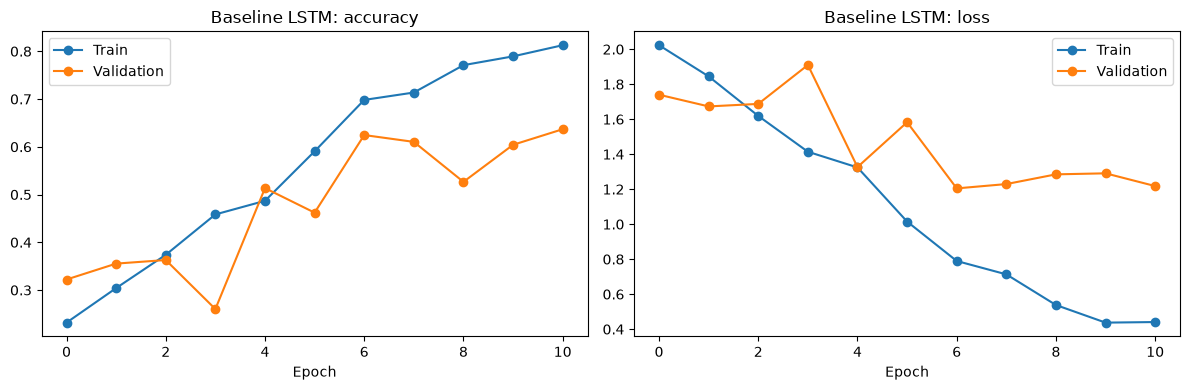

In [ ]:
def plot_history(hist, title, filename):
    """Plot training vs validation accuracy and loss to diagnose over/underfitting."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.history["accuracy"], marker="o", label="Train")
    axes[0].plot(hist.history["val_accuracy"], marker="o", label="Validation")
    axes[0].set_title(f"{title}: accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(hist.history["loss"], marker="o", label="Train")
    axes[1].plot(hist.history["val_loss"], marker="o", label="Validation")
    axes[1].set_title(f"{title}: loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

plot_history(history, "Baseline LSTM", "baseline_learning_curves.png")

### Interpreting the baseline learning curves

**Accuracy:** training accuracy climbs to 0.81; validation stalls at ~0.62.

**Loss:** training loss falls to 0.44; validation loss bottoms out at
epoch 6, then rises.

**Diagnosis — overfitting.** The widening gap shows the model memorising its
19,903 training passages instead of learning style that transfers to unseen text.
Rising validation loss means it is becoming confidently wrong on new passages.

Early stopping caught this: validation loss was lowest at epoch 6, so training
halted at epoch 10 and restored those weights.

**Implication.** Overfitting here means too little data for the model's capacity.
Section 8 addresses it by splitting each passage into three 200-word chunks,
tripling the training set to 59,709 sequences, rather than shrinking the network.

### 7.3 Test set results

In [25]:
# Evaluation functions
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

def evaluate(model, dataset, true_labels, label_prefix="Model"):
    """Return predictions plus headline metrics for a fitted model."""
    probs = model.predict(dataset, verbose=0)
    preds = probs.argmax(axis=1)
    acc = accuracy_score(true_labels, preds)
    macro = f1_score(true_labels, preds, average="macro")
    weighted = f1_score(true_labels, preds, average="weighted")
    print(f"{label_prefix} | Accuracy: {acc:.4f} | Macro F1: {macro:.4f} | Weighted F1: {weighted:.4f}")
    return probs, preds, {"accuracy": acc, "macro_f1": macro, "weighted_f1": weighted}

y_test = test_df["label"].values
probs, preds, baseline_scores = evaluate(model, test_ds, y_test, "Baseline")

target_names = [f"{idx_to_author[i]} ({AUTHOR_NAMES.get(idx_to_author[i], '?')})"
                for i in range(len(authors))]
print()
print(classification_report(y_test, preds, target_names=target_names, digits=3))

Baseline | Accuracy: 0.6326 | Macro F1: 0.6002 | Weighted F1: 0.6275

                            precision    recall  f1-score   support

         8 (James Baldwin)      0.736     0.604     0.663      1037
        14 (Ralph Emerson)      0.459     0.289     0.355       405
         19 (Thomas Hardy)      0.479     0.857     0.615       231
    21 (Washington Irving)      0.665     0.419     0.514       346
           26 (Bret Harte)      0.895     0.931     0.912       666
33 (George William Curtis)      0.652     0.771     0.706       262
         37 (Jacob Abbott)      0.623     0.447     0.520       358
           39 (James Payn)      0.611     0.729     0.665       340
         45 (Oliver Optic)      0.379     0.530     0.442       347
48 (Thomas Anstey Guthrie)      0.524     0.725     0.608       273

                  accuracy                          0.633      4265
                 macro avg      0.602     0.630     0.600      4265
              weighted avg      0.648     0.

### 7.4 Confusion matrix

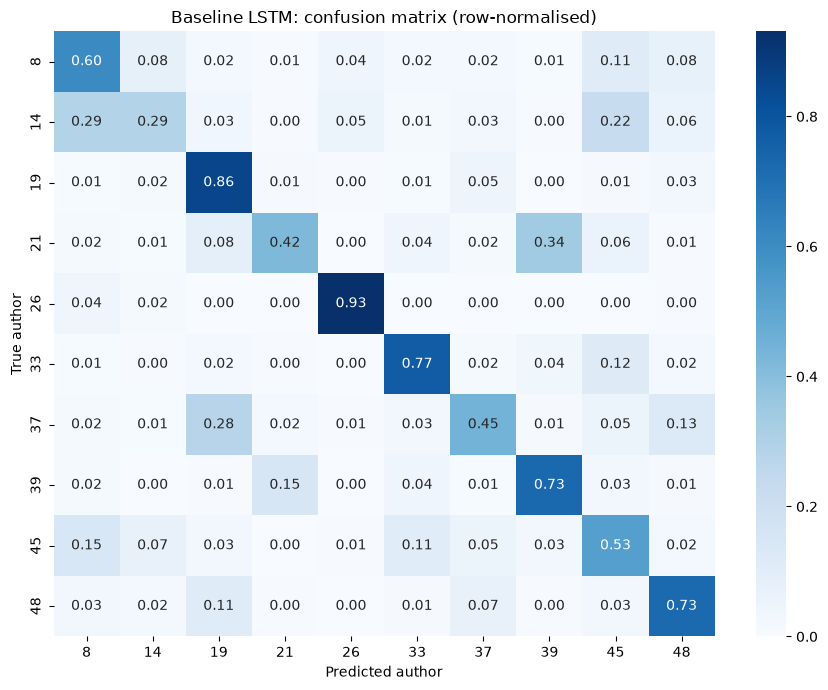

Most confused pairs (true -> predicted, rate):
  21 -> 39: 34.39%
  14 -> 8: 28.89%
  37 -> 19: 27.65%
  14 -> 45: 22.22%
  39 -> 21: 15.00%


In [26]:
# Confusion matrix: row-normalised, so each row shows where that author's passages went
def plot_confusion(y_true, y_pred, filename, title="Confusion matrix"):
    """Row-normalised confusion matrix: each row shows where that author's passages went."""
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=[idx_to_author[i] for i in range(len(authors))],
                yticklabels=[idx_to_author[i] for i in range(len(authors))])
    plt.title(title); plt.xlabel("Predicted author"); plt.ylabel("True author")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    return cm

cm = plot_confusion(y_test, preds, "baseline_confusion_matrix.png",
                    "Baseline LSTM: confusion matrix (row-normalised)")

# Most confused author pairs, to discuss in the report
np.fill_diagonal(cm, 0)
pairs = [(idx_to_author[i], idx_to_author[j], cm[i, j])
         for i in range(len(authors)) for j in range(len(authors)) if cm[i, j] > 0]
top_pairs = sorted(pairs, key=lambda p: -p[2])[:5]
print("Most confused pairs (true -> predicted, rate):")
for t, p, r in top_pairs:
    print(f"  {t} -> {p}: {r:.2%}")

The classification report identifies the authors with the highest and lowest precision, recall and F1 scores. The confusion matrix then shows the specific author pairs that are most often mixed up. Poorer performance may occur when authors share a genre, subject matter or historical period, because their vocabulary and sentence patterns can be similar. These results guide the choice of shorter chunks, bidirectional context and passage-level voting in the improved model.

---
## 8. Retraining with improved parameters

The baseline uses the first 250 words of each passage. The retraining experiment creates three non-overlapping 200-word chunks from each passage, increasing the number of training examples and reducing the sequence length processed at one time. The second model is bidirectional, so it can use information from both the beginning and end of each chunk, and dropout is increased from 0.3 to 0.4 to reduce overfitting.

Chunks are created only after the passage-level train, validation and test split. This is essential: if chunks were created before splitting, pieces of the same original passage could appear in different sets, causing leakage and overly optimistic results. The improved model is judged using both individual chunk predictions and passage-level probability voting.

In [27]:
# Split passages into chunks
CHUNK_LEN = 200
N_CHUNKS  = 3

def to_chunks(frame):
    """Split each passage into N_CHUNKS non-overlapping chunks of CHUNK_LEN words."""
    rows = []
    for passage_id, text, label in zip(frame["passage_id"], frame["text_600"], frame["label"]):
        words = text.split()
        for k in range(N_CHUNKS):
            piece = words[k * CHUNK_LEN:(k + 1) * CHUNK_LEN]
            if len(piece) == CHUNK_LEN:          # drop any short tail
                rows.append((passage_id, " ".join(piece), label))
    return pd.DataFrame(rows, columns=["passage_id", "text_chunk", "label"])

train_chunks = to_chunks(train_df)
val_chunks   = to_chunks(val_df)
test_chunks  = to_chunks(test_df)
print(f"Chunks -> train: {len(train_chunks)}  val: {len(val_chunks)}  test: {len(test_chunks)}")

# Re-fit the vectoriser for the shorter sequence length, on training chunks only
vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_mode="int",
                               output_sequence_length=CHUNK_LEN)
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(train_chunks["text_chunk"].values).batch(256))

train_ds2 = make_dataset(train_chunks, "text_chunk", shuffle=True)
val_ds2   = make_dataset(val_chunks, "text_chunk")
test_ds2  = make_dataset(test_chunks, "text_chunk")

Chunks -> train: 59709  val: 12795  test: 12795


In [28]:
model_v2 = models.Sequential([
    layers.Input(shape=(CHUNK_LEN,), dtype="int32"),
    layers.Embedding(VOCAB_SIZE, 128, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64)),   # reads the text forwards and backwards
    layers.Dropout(0.4),
    layers.Dense(len(authors), activation="softmax"),
], name="improved_bilstm")

model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

weights2 = compute_class_weight("balanced", classes=np.arange(len(authors)),
                                y=train_chunks["label"].values)
class_weights2 = dict(enumerate(weights2))

callbacks2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("models/improved_bilstm.keras",
                                       monitor="val_accuracy", save_best_only=True),
]

start = time.time()
history2 = model_v2.fit(train_ds2, validation_data=val_ds2, epochs=EPOCHS,
                        class_weight=class_weights2, callbacks=callbacks2, verbose=1)
improved_minutes = (time.time() - start) / 60
print(f"Training time: {improved_minutes:.1f} minutes")

Epoch 1/15


c:\Users\USER-PC\Desktop\PDAN Assignments\PDAnalytics\POE\Task_1\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


933/933 ━━━━━━━━━━━━━━━━━━━━ 143s 150ms/step - accuracy: 0.2893 - loss: 1.8323 - val_accuracy: 0.3790 - val_loss: 1.5705
Epoch 2/15
933/933 ━━━━━━━━━━━━━━━━━━━━ 131s 140ms/step - accuracy: 0.4849 - loss: 1.2940 - val_accuracy: 0.3669 - val_loss: 1.5862
Epoch 3/15
933/933 ━━━━━━━━━━━━━━━━━━━━ 129s 139ms/step - accuracy: 0.4662 - loss: 1.3727 - val_accuracy: 0.5818 - val_loss: 1.1443
Epoch 4/15
933/933 ━━━━━━━━━━━━━━━━━━━━ 132s 141ms/step - accuracy: 0.6533 - loss: 0.9004 - val_accuracy: 0.6347 - val_loss: 1.0330
Epoch 5/15
933/933 ━━━━━━━━━━━━━━━━━━━━ 135s 144ms/step - accuracy: 0.7517 - loss: 0.7050 - val_accuracy: 0.7547 - val_loss: 0.7347
Epoch 6/15
933/933 ━━━━━━━━━━━━━━━━━━━━ 136s 145ms/step - accuracy: 0.8471 - loss: 0.4948 - val_accuracy: 0.8309 - val_loss: 0.5685
Epoch 7/15
933/933 ━━━━━━━━━━━━━━━━━━━━ 134s 143ms/step - accuracy: 0.9050 - loss: 0.3212 - val_accuracy: 0.8207 - val_loss: 0.6434
Epoch 8/15
933/933 ━━━━━━━━━━━━━━━━━━━━ 135s 145ms/step - accuracy: 0.9348 - loss: 0.21

### 8.1 Evaluating the retrained model

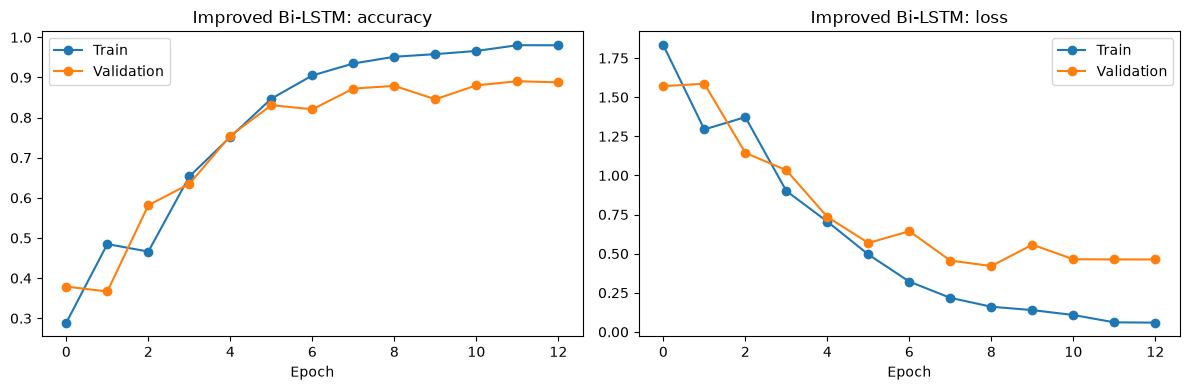

Improved (per chunk) | Accuracy: 0.8782 | Macro F1: 0.8640 | Weighted F1: 0.8790

                            precision    recall  f1-score   support

         8 (James Baldwin)      0.946     0.866     0.904      3111
        14 (Ralph Emerson)      0.856     0.900     0.878      1215
         19 (Thomas Hardy)      0.889     0.811     0.848       693
    21 (Washington Irving)      0.868     0.868     0.868      1038
           26 (Bret Harte)      0.948     0.981     0.964      1998
33 (George William Curtis)      0.807     0.934     0.866       786
         37 (Jacob Abbott)      0.742     0.823     0.781      1074
           39 (James Payn)      0.959     0.852     0.902      1020
         45 (Oliver Optic)      0.745     0.874     0.805      1041
48 (Thomas Anstey Guthrie)      0.892     0.766     0.824       819

                  accuracy                          0.878     12795
                 macro avg      0.865     0.868     0.864     12795
              weighted avg      

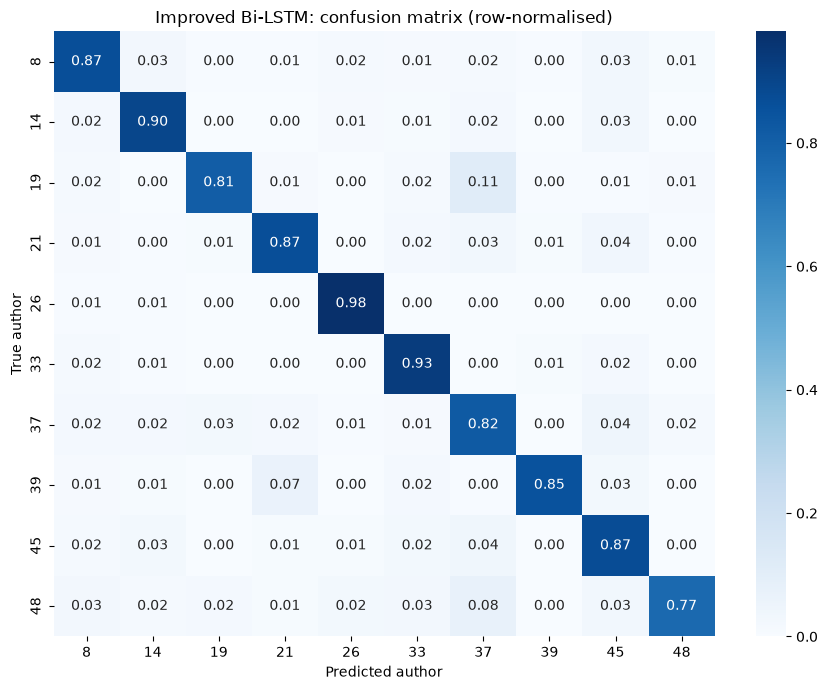

array([[8.66280939e-01, 2.86081646e-02, 3.85728062e-03, 5.14304082e-03,
        1.76792028e-02, 1.38219222e-02, 1.70363227e-02, 4.17872067e-03,
        3.34297653e-02, 9.96464159e-03],
       [2.13991770e-02, 9.00411523e-01, 8.23045267e-04, 0.00000000e+00,
        1.15226337e-02, 9.87654321e-03, 2.05761317e-02, 0.00000000e+00,
        3.20987654e-02, 3.29218107e-03],
       [1.87590188e-02, 1.44300144e-03, 8.10966811e-01, 1.44300144e-02,
        1.44300144e-03, 1.58730159e-02, 1.13997114e-01, 4.32900433e-03,
        7.21500722e-03, 1.15440115e-02],
       [1.44508671e-02, 4.81695568e-03, 7.70712909e-03, 8.68015414e-01,
        0.00000000e+00, 2.11946050e-02, 3.17919075e-02, 1.05973025e-02,
        3.75722543e-02, 3.85356455e-03],
       [5.00500501e-03, 5.00500501e-03, 5.00500501e-04, 0.00000000e+00,
        9.80980981e-01, 1.00100100e-03, 2.50250250e-03, 0.00000000e+00,
        3.50350350e-03, 1.50150150e-03],
       [1.90839695e-02, 5.08905852e-03, 0.00000000e+00, 3.81679389e-03,
   

In [29]:
plot_history(history2, "Improved Bi-LSTM", "improved_learning_curves.png")

y_test2 = test_chunks["label"].values
probs2, preds2, improved_scores = evaluate(model_v2, test_ds2, y_test2, "Improved (per chunk)")
print()
print(classification_report(y_test2, preds2, target_names=target_names, digits=3))
plot_confusion(y_test2, preds2, "improved_confusion_matrix.png",
               "Improved Bi-LSTM: confusion matrix (row-normalised)")

### 8.2 Passage-level voting

Each test passage produces three chunk predictions. Averaging the probabilities across a passage's chunks is a form of ensembling, and usually beats any single chunk: it is also how the bot should work when a fan pastes in a long extract.

In [30]:

vote = test_chunks[["passage_id", "label"]].copy()
vote[[f"p{i}" for i in range(len(authors))]] = probs2

passage_level = vote.groupby("passage_id").agg(
    {**{f"p{i}": "mean" for i in range(len(authors))}, "label": "first"})
passage_preds = passage_level[[f"p{i}" for i in range(len(authors))]].values.argmax(axis=1)
passage_true  = passage_level["label"].values

voted_scores = {
    "accuracy":    accuracy_score(passage_true, passage_preds),
    "macro_f1":    f1_score(passage_true, passage_preds, average="macro"),
    "weighted_f1": f1_score(passage_true, passage_preds, average="weighted"),
}
print("Improved (passage-level vote) |",
      " | ".join(f"{k}: {v:.4f}" for k, v in voted_scores.items()))

Improved (passage-level vote) | accuracy: 0.9531 | macro_f1: 0.9462 | weighted_f1: 0.9534


### 8.3 Comparison table for the report

In [31]:

comparison = pd.DataFrame([
    {"Model": "Baseline LSTM (250-word passages)", **baseline_scores,
     "training_minutes": round(baseline_minutes, 1)},
    {"Model": "Improved Bi-LSTM (200-word chunks)", **improved_scores,
     "training_minutes": round(improved_minutes, 1)},
    {"Model": "Improved Bi-LSTM + passage voting", **voted_scores,
     "training_minutes": round(improved_minutes, 1)},
]).round(4)

comparison.to_csv("report/model_comparison.csv", index=False)
comparison

,Model,accuracy,macro_f1,weighted_f1,training_minutes
0,Baseline LSTM (250-word passages),0.6326,0.6002,0.6275,6.5
1,Improved Bi-LSTM (200-word chunks),0.8782,0.8640,0.8790,29.3
2,Improved Bi-LSTM + passage voting,0.9531,0.9462,0.9534,29.3


The comparison table reports accuracy, macro F1, weighted F1 and training time for the baseline, the improved Bi-LSTM at chunk level, and the improved Bi-LSTM after passage-level voting. The improved method is considered successful only if its test metrics improve without an unacceptable increase in training time. Passage-level voting is especially important because the final application makes one author prediction for a whole passage, not for an isolated chunk.

---
## 9. The author-guessing bot

This is the deliverable the client actually uses: paste in a passage, get a guess with a confidence score. The model returns a probability for every author, and the bot declines to answer when its best guess is weak, so fans are not given a confident wrong answer.

In [32]:
# Guess the author of a given text
def guess_author(text, model=model_v2, chunk_len=CHUNK_LEN,
                 confidence_threshold=0.40, top_k=3):
    """Guess who wrote a passage. Long text is split into chunks and averaged."""
    words = text.lower().split()
    if len(words) < 50:
        return "Please paste at least 50 words so I have enough style to work with."

    chunks = [" ".join(words[i:i + chunk_len]) for i in range(0, len(words), chunk_len)]
    chunks = [c for c in chunks if len(c.split()) >= 50]

    probs = model.predict(vectorizer(tf.constant(chunks)), verbose=0).mean(axis=0)
    order = probs.argsort()[::-1][:top_k]

    best_id = idx_to_author[order[0]]
    best_name = AUTHOR_NAMES.get(best_id, f"Author {best_id}")

    if probs[order[0]] < confidence_threshold:
        lines = ["I am not confident about this one. My closest matches are:"]
    else:
        lines = [f"My guess: {best_name} ({probs[order[0]]:.0%} confident)", "", "Runners-up:"]

    for i in order:
        author_id = idx_to_author[i]
        lines.append(f"  {AUTHOR_NAMES.get(author_id, f'Author {author_id}')}: {probs[i]:.0%}")
    return "\n".join(lines)

In [33]:
# Test the model on a sample passage
sample = test_df.iloc[0]
print("True author:", sample["author"], AUTHOR_NAMES.get(sample["author"], ""))
print()
print(guess_author(sample["text_600"]))

True author: 8 James Baldwin

My guess: James Baldwin (83% confident)

Runners-up:
  James Baldwin: 83%
  Thomas Anstey Guthrie: 14%
  Washington Irving: 1%


In [34]:
# Try it on a short passage (less than 50 words)
short_passage = "It was a dark and stormy night. The wind howled through the trees, and the rain lashed against the windows. I could hear the distant rumble of thunder as I sat alone in my study, pondering the mysteries of the universe."
print(guess_author(short_passage))

Please paste at least 50 words so I have enough style to work with.


In [35]:
# Try it on a passage from a different author not in the training set
external_passage = """It was the best of times, it was the worst of times, it was the age of wisdom, it was the age of foolishness, it was the epoch of belief, it was the epoch of incredulity, it was the season of Light, it was the season of Darkness, it was the spring of hope, it was the winter of despair, we had everything before us, we had nothing before us, we were all going direct to Heaven, we were all going direct the other way – in short, the period was so far like the present period, that some of its noisiest authorities insisted on its being received, for good or for evil, in the superlative degree of comparison only."""
print(guess_author(external_passage))

My guess: Oliver Optic (52% confident)

Runners-up:
  Oliver Optic: 52%
  Washington Irving: 20%
  Jacob Abbott: 12%


---
## 10. Saving outputs and closing Spark

In [36]:
# Save artefacts referenced by the report
comparison.to_csv("report/model_comparison.csv", index=False)
pd.DataFrame(history.history).to_csv("report/baseline_history.csv", index=False)
pd.DataFrame(history2.history).to_csv("report/improved_history.csv", index=False)
print("Figures saved to:", FIG_DIR)
print(os.listdir(FIG_DIR))

spark.stop()
print("Spark session stopped.")

Figures saved to: report/figures
['baseline_confusion_matrix.png', 'baseline_learning_curves.png', 'improved_confusion_matrix.png', 'improved_learning_curves.png']
Spark session stopped.


## 11. References and code documentation

**References**
- Gungor, A. (2018) *Victorian Era Authorship Attribution* [Dataset]. UCI Machine Learning Repository. Available at: https://archive.ics.uci.edu/dataset/454/victorian+era+authorship+attribution


**Code Documentation**
- TensorFlow documentation: https://www.tensorflow.org/api_docs
- Keras documentation: https://keras.io/api/
- Apache Spark documentation: https://spark.apache.org/docs/latest/
- scikit-learn documentation: https://scikit-learn.org/stable/